# Decision tree classification
1. import the necessory libraries

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree

In [3]:
df=sns.load_dataset("titanic")

In [4]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [5]:
x=df[['pclass','sex','age','sibsp','parch','fare']]
y=df['survived']

In [6]:
x

,pclass,sex,age,sibsp,parch,fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000
887,1,female,19.0,0,0,30.0000
888,3,female,NaN,1,2,23.4500
889,1,male,26.0,0,0,30.0000


In [7]:
x=pd.get_dummies(x,columns=['sex'])

In [8]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [9]:
x

,pclass,age,sibsp,parch,fare,sex_female,sex_male
0,3,22.0,1,0,7.2500,False,True
1,1,38.0,1,0,71.2833,True,False
2,3,26.0,0,0,7.9250,True,False
3,1,35.0,1,0,53.1000,True,False
4,3,35.0,0,0,8.0500,False,True
...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,False,True
887,1,19.0,0,0,30.0000,True,False
888,3,NaN,1,2,23.4500,True,False
889,1,26.0,0,0,30.0000,False,True


In [10]:
x.isnull().sum()

pclass          0
age           177
sibsp           0
parch           0
fare            0
sex_female      0
sex_male        0
dtype: int64

In [11]:
x.age.fillna(value=x.age.mean(), inplace=True)

C:\Users\Hair\AppData\Local\Temp\ipykernel_11336\568294923.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x.age.fillna(value=x.age.mean(), inplace=True)


In [12]:
x.isnull().sum()

pclass        0
age           0
sibsp         0
parch         0
fare          0
sex_female    0
sex_male      0
dtype: int64

In [13]:
x

,pclass,age,sibsp,parch,fare,sex_female,sex_male
0,3,22.000000,1,0,7.2500,False,True
1,1,38.000000,1,0,71.2833,True,False
2,3,26.000000,0,0,7.9250,True,False
3,1,35.000000,1,0,53.1000,True,False
4,3,35.000000,0,0,8.0500,False,True
...,...,...,...,...,...,...,...
886,2,27.000000,0,0,13.0000,False,True
887,1,19.000000,0,0,30.0000,True,False
888,3,29.699118,1,2,23.4500,True,False
889,1,26.000000,0,0,30.0000,False,True


In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [15]:
x_train,x_test,y_train,y_test

(     pclass        age  sibsp  parch      fare  sex_female  sex_male
 122       2  32.500000      1      0   30.0708       False      True
 265       2  36.000000      0      0   10.5000       False      True
 279       3  35.000000      1      1   20.2500        True     False
 662       1  47.000000      0      0   25.5875       False      True
 329       1  16.000000      0      1   57.9792        True     False
 ..      ...        ...    ...    ...       ...         ...       ...
 843       3  34.500000      0      0    6.4375       False      True
 268       1  58.000000      0      1  153.4625        True     False
 775       3  18.000000      0      0    7.7500       False      True
 159       3  29.699118      8      2   69.5500       False      True
 576       2  34.000000      0      0   13.0000        True     False
 
 [712 rows x 7 columns],
      pclass        age  sibsp  parch      fare  sex_female  sex_male
 596       2  29.699118      0      0   33.0000        True    

In [16]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred=model.predict(x_test)

In [18]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.7877094972067039


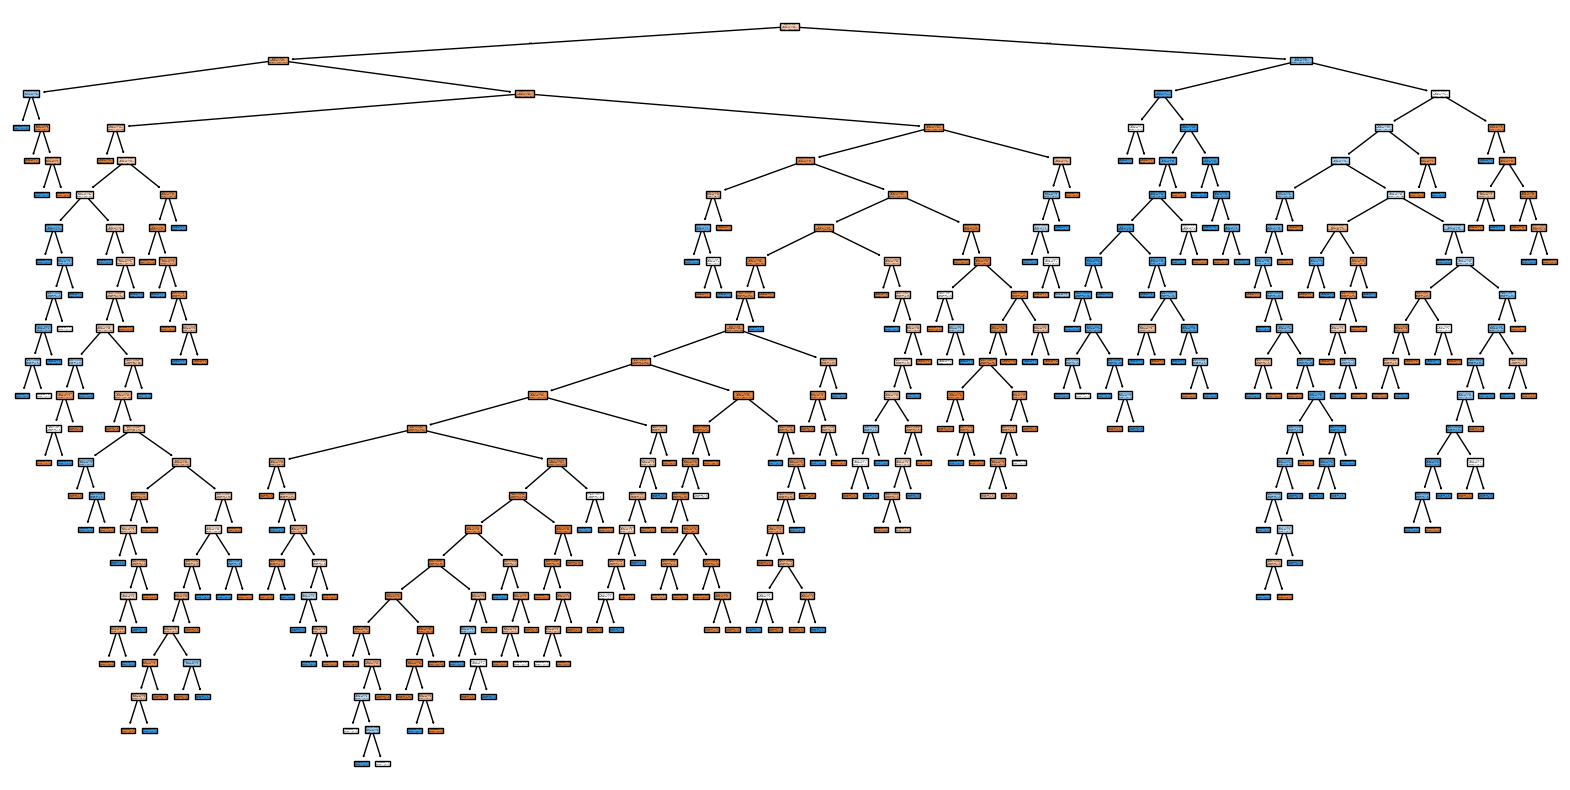

In [19]:
import matplotlib.pyplot as plt
from sklearn import tree
# ... assume model, x, and y are defined and data is loaded ...

# Create a figure object and fit the model in one line
fig = plt.figure(figsize=(20, 10)) # Optional: adjust figure size for readability
tree.plot_tree(model.fit(x, y), filled=True)

# Save the figure first
plt.savefig("tree.net.png") # The saved file will be correct

# Then display the figure
plt.show()


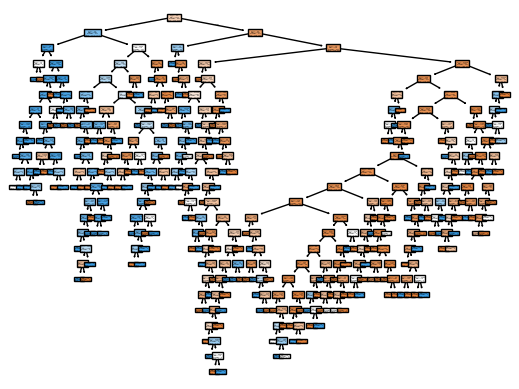

<Figure size 640x480 with 0 Axes>

In [20]:
tree.plot_tree(model.fit(x,y),filled=True)
plt.show()
plt.savefig("tree.png")

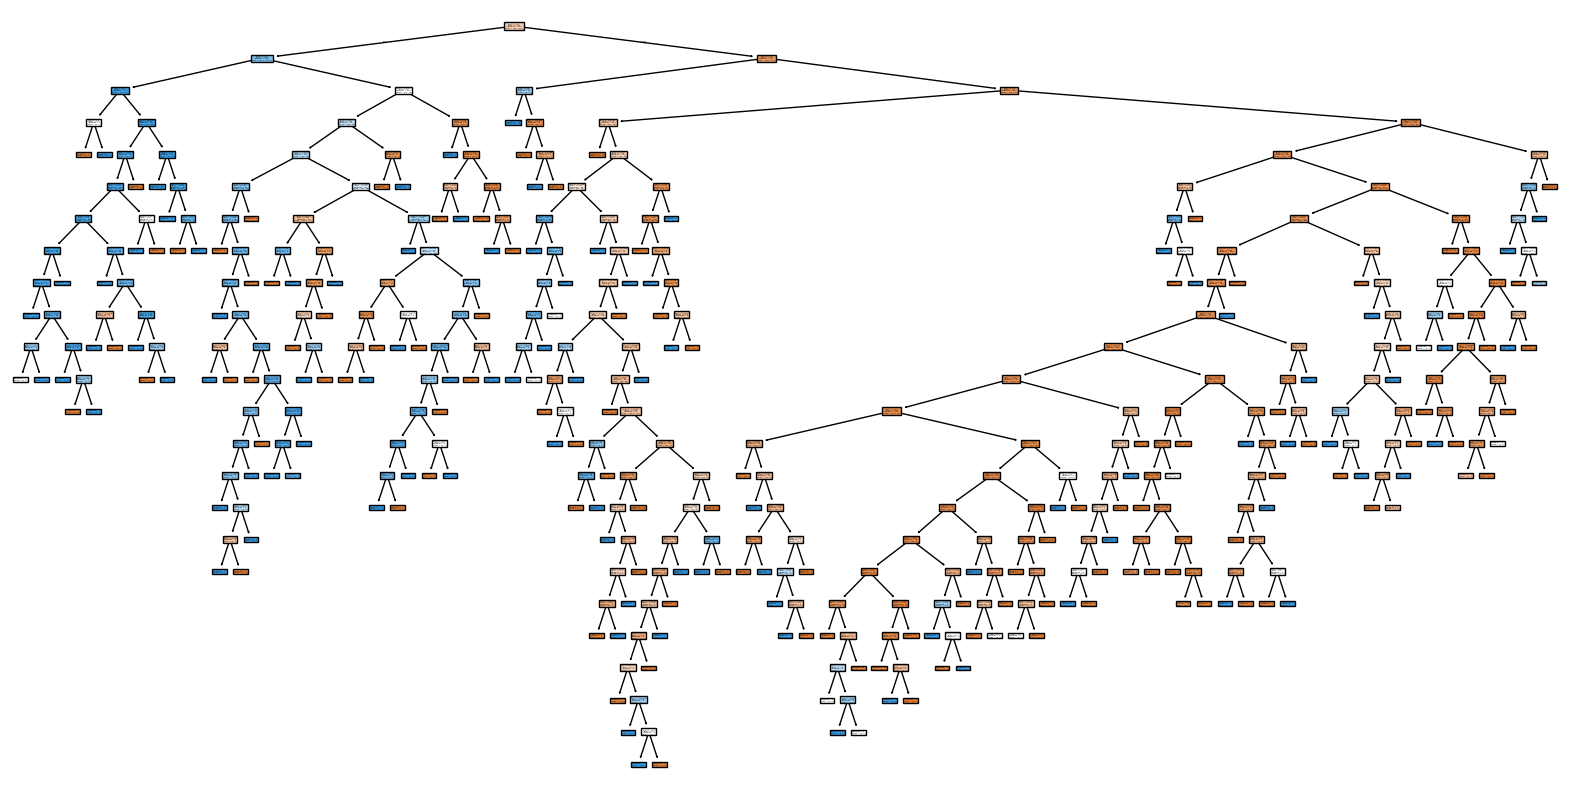

<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(model.fit(x,y),filled=True)
plt.show()
plt.savefig("decision_tree.pdf",format="pdf",dpi=300)

In [22]:
# precision
from sklearn.metrics import precision_score, recall_score, f1_score
precision_score(y_test,y_pred)

0.75

In [23]:
recall_score(y_test,y_pred)

0.7083333333333334

In [24]:
f1_score(y_test,y_pred)

0.7285714285714285

# precision: precision measures the proportion of true positive predictions among all positive predictios

In [25]:
# precision
from sklearn.metrics import precision_score, recall_score, f1_score
precision_score(y_test,y_pred)

0.75

# Recall: Recall measures the proportion of true positive predictions among all actual positive instances

In [26]:
recall_score(y_test,y_pred)

0.7083333333333334

In [27]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[90, 17],
       [21, 51]])

<Axes: >

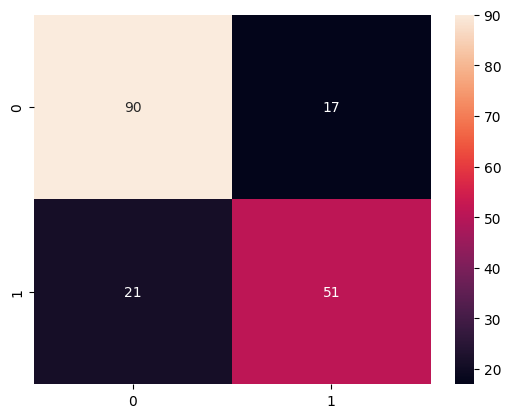

In [28]:
sns.heatmap(cm,annot=True)

<Axes: >

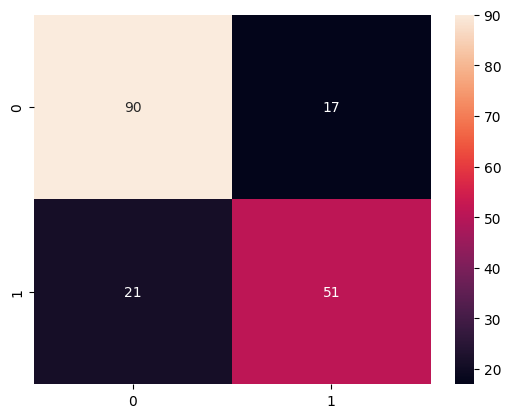

In [29]:
sns.heatmap(cm,annot=True,fmt='d')

Text(0.5, 23.52222222222222, 'predicted label')

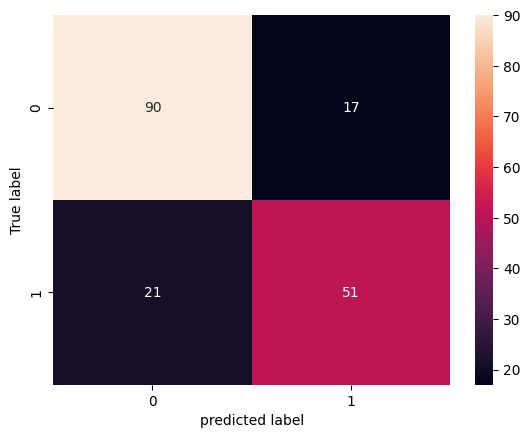

In [30]:
sns.heatmap(cm,annot=True)
plt.ylabel('True label')
plt.xlabel("predicted label")

# K Nearest Neighbours(KNN)

In [31]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[90, 17],
       [29, 43]])

In [32]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=1)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[88, 19],
       [26, 46]])

In [33]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=2)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[100,   7],
       [ 40,  32]])

In [34]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
# y_pred=model.predict(x_test)
# cm=confusion_matrix(y_test,y_pred)
# cm

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [35]:
precision_score(y_test,y_pred)

0.8205128205128205

In [36]:
recall_score(y_test,y_pred)

0.4444444444444444

Text(0.5, 23.52222222222222, 'predicted label')

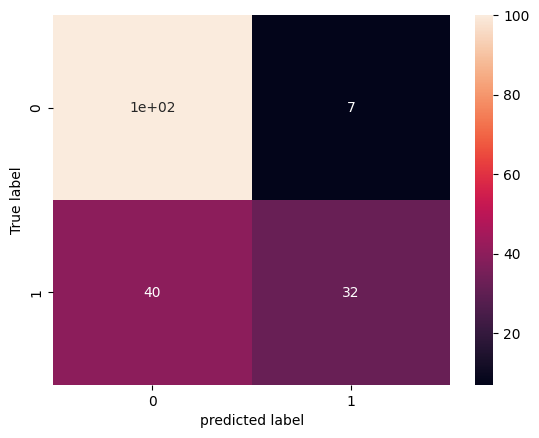

In [37]:
sns.heatmap(cm,annot=True)
plt.ylabel('True label')
plt.xlabel('predicted label')

# Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[94, 13],
       [20, 52]])

In [39]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",cm)

precision_score: 0.7910447761194029
recall_score: 0.7361111111111112
f1_score: 0.762589928057554
confusion_matrix: [[93 14]
 [19 53]]


# Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",cm)

precision_score: 0.7945205479452054
recall_score: 0.8055555555555556
f1_score: 0.8
confusion_matrix: [[92 15]
 [14 58]]


c:\Users\Hair\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Support Vector Machines (SVM)

In [41]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",cm)

precision_score: 0.71875
recall_score: 0.3194444444444444
f1_score: 0.4423076923076923
confusion_matrix: [[98  9]
 [49 23]]


# NAIVE Bayes

In [42]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",cm)

precision_score: 0.8307692307692308
recall_score: 0.75
f1_score: 0.7883211678832117
confusion_matrix: [[96 11]
 [18 54]]


In [43]:
# libraries and model import
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# define the models to be evaluated
models=[LogisticRegression(),KNeighborsClassifier(),RandomForestClassifier(),SVC()]
names=["LogisticRegression","KNN","Random Forest","SVM"]
# perform k-fold cross-validation for each model
k=10
for name,model in zip(names,models):
    cv_scores=cross_val_score(model,x_train,y_train,cv=k)
    print(f"{name}: cv accuracy: {np.mean(cv_scores):.3f} (+/- {np.std(cv_scores): .3f})")


c:\Users\Hair\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Hair\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/prepr

LogisticRegression: cv accuracy: 0.778 (+/-  0.033)
KNN: cv accuracy: 0.690 (+/-  0.043)
Random Forest: cv accuracy: 0.798 (+/-  0.047)
SVM: cv accuracy: 0.683 (+/-  0.033)


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
# define the parameter grid
param_grid = {'C': [0.1, 1, 10],'kernel': ['linear', 'rbf'],'gamma': [0.1, 1, 10]}
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(x_train,y_train)
print("Best parameters:{}",format(grid_search.best_params_))
print("Best cross_validation Score:(:.2f)".format(grid_search.best_score_))

Best parameters:{} {'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}
Best cross_validation Score:(:.2f)


In [1]:
from sklearn.model_selection import GridSearchCV 
from sklearn.svm import SVC # Import SVC class
import numpy as np # Import numpy for creating dummy data

# --- Example of creating dummy data for demonstration ---
# In a real scenario, you would use your actual x_train and y_train data
x_train = np.random.rand(100, 5) 
y_train = np.random.randint(0, 2, 100) 

# Define the parameter grid
param_grid = {'C': [0.1, 1, 10],
              'kernel': ['linear', 'rbf'],
              'gamma': [0.1, 1, 10]} 

# Initialize GridSearchCV with the SVC model, parameter grid, and 5-fold cross-validation
grid_search = GridSearchCV(SVC(), param_grid, cv=5) 

# Fit the model (this will test all combinations in param_grid)
grid_search.fit(x_train, y_train) 

# Print the best parameters found
print("Best parameters:{}".format(grid_search.best_params_)) 

# Print the best cross-validation score
# Note: the original code had a syntax error in the format string (missing f-string prefix)
print("Best cross_validation Score:{:.2f}".format(grid_search.best_score_))


Best parameters:{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}
Best cross_validation Score:0.52
